# 💨 Day 26 - Air Quality Index (AQI) Prediction
### End-to-end model to estimate daily AQI levels using key pollutant features and Random Forest regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

sns.set(style="whitegrid")

# -------- CONFIG --------
FILENAME = "city_day.csv"   # file in working dir
CITY = None                 # set e.g. "Delhi" to restrict to one city, or keep None to use all cities
USE_LAG = True              # keep True for AQI_lag1 (recommended)
TEST_FRAC = 0.2
RANDOM_STATE = 42
# ------------------------

In [2]:
# 1) Load & prepare
df = pd.read_csv(FILENAME)
# standardize date column name (many datasets use "Date")
date_col = next((c for c in df.columns if c.lower() in ("date","datetime","timestamp")), "Date")
df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df = df.dropna(subset=[date_col]).sort_values([date_col]).reset_index(drop=True)
df.rename(columns={date_col: "Date"}, inplace=True)

if CITY:
    df = df[df['City'] == CITY].sort_values('Date').reset_index(drop=True)

# keep only needed columns if present
keep = ['Date','AQI','PM2.5','PM10','CO','NO2','O3','SO2']
df = df[[c for c in keep if c in df.columns]].copy()

In [3]:
# 2) simple lag
if USE_LAG:
    df = df.sort_values('Date').reset_index(drop=True)
    df['AQI_lag1'] = df['AQI'].shift(1)
    df = df.dropna(subset=['AQI','AQI_lag1']).reset_index(drop=True)

In [4]:
# 3) features / target
feature_cols = ['PM2.5','PM10','CO','NO2','O3','SO2']
feature_cols = [c for c in feature_cols if c in df.columns]
if USE_LAG and 'AQI_lag1' in df.columns:
    feature_cols.append('AQI_lag1')

df = df.dropna(subset=['AQI']).reset_index(drop=True)
X = df[feature_cols].copy()
y = df['AQI'].astype(float).copy()
dates = df['Date'].copy()

In [5]:
# 4) impute + scale
imp = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_imp = imp.fit_transform(X)
X_scaled = scaler.fit_transform(X_imp)

In [6]:
# 5) time-aware split (last TEST_FRAC as test)
n = len(X_scaled)
split = int(n * (1 - TEST_FRAC))
X_train, X_test = X_scaled[:split], X_scaled[split:]
y_train, y_test = y.values[:split], y.values[split:]
dates_train, dates_test = dates[:split], dates[split:]

print(f"Rows total: {n}, Train: {len(X_train)}, Test: {len(X_test)}")
print("Features:", feature_cols)

Rows total: 21313, Train: 17050, Test: 4263
Features: ['PM2.5', 'PM10', 'CO', 'NO2', 'O3', 'SO2', 'AQI_lag1']


In [7]:
# 6) train RF
model = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [8]:
# 7) metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.4f}")

MAE: 16.19, RMSE: 27.25, R2: 0.8998


In [9]:
# 8) save pipeline (optional)
joblib.dump({'model': model, 'imputer': imp, 'scaler': scaler, 'features': feature_cols}, "aqi_simple_pipeline.joblib")

['aqi_simple_pipeline.joblib']

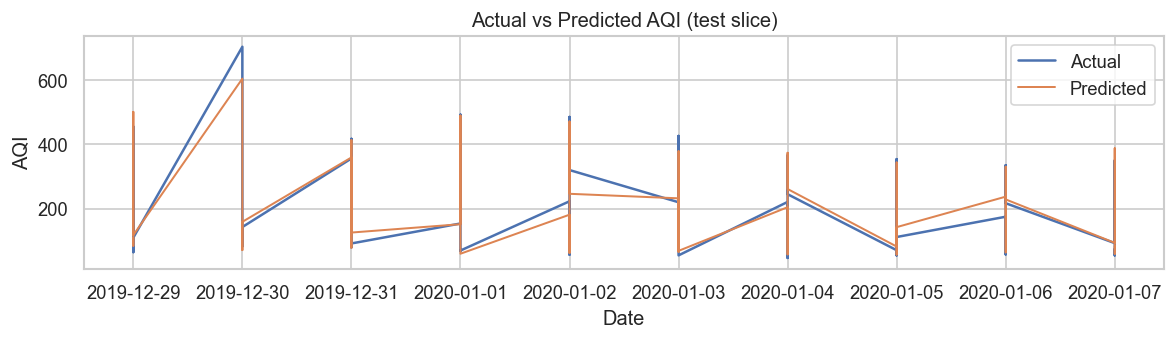

In [10]:
# ---------- PLOTS ----------
plt.rcParams.update({"figure.dpi":120})

# A) Actual vs Predicted (time series slice)
n_plot = min(200, len(y_test))
plt.figure(figsize=(10,3))
plt.plot(dates_test.iloc[:n_plot].values, y_test[:n_plot], label='Actual', linewidth=1.5)
plt.plot(dates_test.iloc[:n_plot].values, y_pred[:n_plot], label='Predicted', linewidth=1.2)
plt.legend()
plt.title("Actual vs Predicted AQI (test slice)")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.tight_layout()
plt.show()

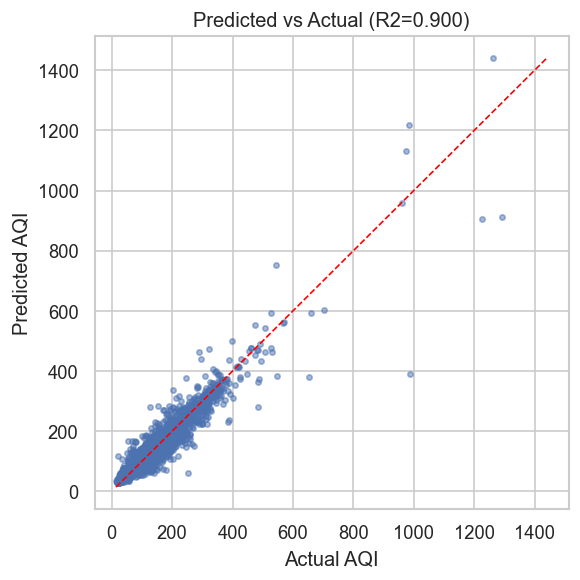

In [11]:
# B) Predicted vs Actual scatter
plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred, alpha=0.5, s=10)
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([mn,mx],[mn,mx], color='red', linewidth=1, linestyle='--')
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title(f"Predicted vs Actual (R2={r2:.3f})")
plt.tight_layout()
plt.show()

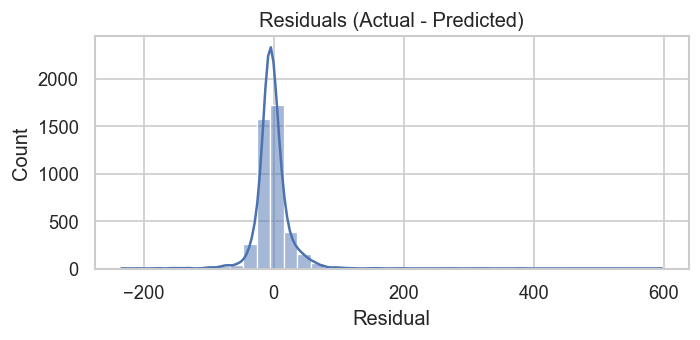

In [12]:
# C) Residuals histogram
resids = y_test - y_pred
plt.figure(figsize=(6,3))
sns.histplot(resids, kde=True, bins=40)
plt.title("Residuals (Actual - Predicted)")
plt.xlabel("Residual")
plt.tight_layout()
plt.show()

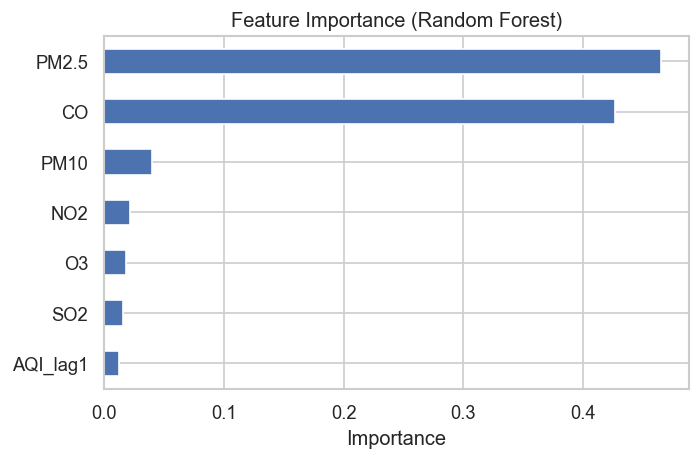

In [13]:
# D) Feature importance (RF)
fi = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)
plt.figure(figsize=(6,4))
fi.plot(kind='barh')
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [14]:
# E) Quick table of first 10 predictions
pred_df = pd.DataFrame({
    'date': dates_test.iloc[:20].values,
    'actual': y_test[:20],
    'predicted': np.round(y_pred[:20],2),
    'residual': np.round(y_test[:20] - y_pred[:20],2)
})
print("\nSample predictions (first 20 test rows):")
print(pred_df.to_string(index=False))


Sample predictions (first 20 test rows):
      date  actual  predicted  residual
2019-12-29   133.0     109.70     23.30
2019-12-29    92.0      99.70     -7.70
2019-12-29   398.0     500.66   -102.67
2019-12-29   322.0     333.39    -11.39
2019-12-29   339.0     315.67     23.33
2019-12-29   146.0     154.64     -8.63
2019-12-29   319.0     320.70     -1.70
2019-12-29   241.0     220.50     20.50
2019-12-29   455.0     466.30    -11.30
2019-12-29   106.0     127.79    -21.79
2019-12-29   193.0     164.32     28.68
2019-12-29   389.0     437.63    -48.63
2019-12-29   160.0     166.81     -6.81
2019-12-29    65.0      84.70    -19.69
2019-12-29   110.0     117.89     -7.89
2019-12-30   703.0     604.02     98.98
2019-12-30   143.0     153.47    -10.47
2019-12-30    83.0      71.44     11.56
2019-12-30   171.0     133.02     37.97
2019-12-30   155.0     141.72     13.28
